In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import importlib

# Funciones auxiliares
import auxfun
importlib.reload(auxfun)

<module 'auxfun' from 'c:\\Users\\Deportivo Estadio\\Desktop\\Master Quant\\Gestión de activos\\Trabajo gestión cuantitativa\\Trabajo_gestion_cuantitativa\\Trabajo_gestion_cuantitativa\\Monitoring\\auxfun.py'>

<Axes: title={'center': 'Cartera vs STOXX50'}>

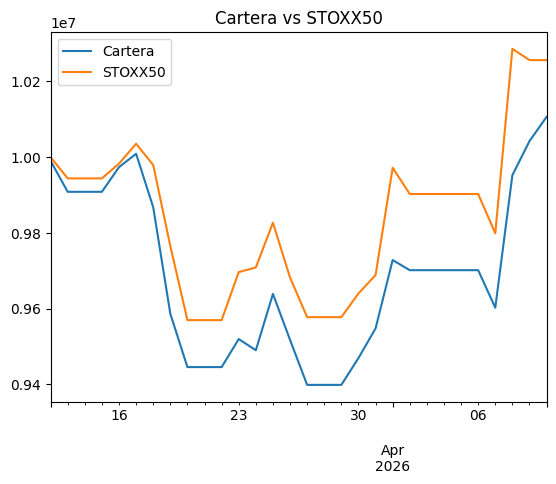

In [11]:
df = pd.read_csv("../mi_cartera/historial_operaciones.csv", parse_dates=["fecha"])
cash = auxfun.calcular_cash_diario(df)
todas_fechas = pd.date_range(start=df['fecha'].min(), end=pd.Timestamp.today(), freq="D")
stoxx_data = yf.download("^STOXX50E", start=todas_fechas.min(), end=todas_fechas.max(), auto_adjust=True, progress=False)["Close"].squeeze()
stoxx_data = stoxx_data.reindex(todas_fechas).ffill()
serie_con_costes = auxfun.valor_cartera_diario(df).reindex(todas_fechas).ffill()
serie_sin_costes = auxfun.valor_cartera_diario(df, incluir_costes=False).reindex(todas_fechas).ffill()

# Normalizamos a 10 millones para comparar con la cartera
stoxx_norm = stoxx_data / stoxx_data.iloc[0] * 10*1e6

pd.DataFrame({
    "Cartera": serie_con_costes,
    # "Cartera sin costes": serie_sin_costes,
    "STOXX50": stoxx_norm
}).plot(title="Cartera vs STOXX50")

In [10]:
import sys
sys.path.append("../")  # o la ruta donde esté auxiliary_functions.py
from auxiliary_functions import build_metrics_table

metrics = build_metrics_table({
    "Cartera": serie_con_costes,
    # "Cartera sin costes": serie_sin_costes,
    "STOXX50": stoxx_norm
}, periods_per_year=365)  # usamos 365 porque la serie es diaria con todos los días del calendario

display(metrics.T)

,Cartera,STOXX50
Rentabilidad total,0.011621,0.025640
Rentabilidad anualizada,0.156519,0.670901
Volatilidad anualizada,0.229099,0.332525
Sharpe,0.745040,1.699668
Sortino,1.155901,3.323766
Max Drawdown,-0.061015,-0.046448
Calmar,2.565260,14.444125
Win rate,0.344828,0.500000
Mejor periodo,0.036479,0.049732
Peor periodo,-0.028519,-0.021444


In [ ]:
print(10*1e6-serie_con_costes['2026-03-12'])
10*1e6-serie_sin_costes['2026-03-12']

9986.8139680475


np.float64(0.0)

In [ ]:
serie = auxfun.valor_cartera_diario(df)
print(serie.head(10))

2026-03-12    9.990013e+06
2026-03-13    9.908388e+06
2026-03-16    9.973624e+06
2026-03-17    1.000886e+07
2026-03-18    9.867523e+06
2026-03-19    9.586113e+06
2026-03-20    9.445183e+06
2026-03-23    9.519219e+06
2026-03-24    9.489678e+06
2026-03-25    9.638564e+06
dtype: float64
